# FRB cosmology constrain from $DM_{IGM} $

Highly uncertain: $\Omega_b, f_{IGM}, \chi, \omega$ (If do wCDM cosmology)

For FRB, cosmology distance is based on the dispersion measure (DM), which defined as
$$ DM=\int_0^{D_z}\frac{n_e(l)}{1+z(l)}dl $$

DM can be splitted into multiple terms:
$$ DM=DM_{MW}+DM_{halo}+DM_{IGM}+\frac{DM_{host}+DM_{src}}{1+z}$$
where $DM_{MW}$ is the DM from the Milky Way, $DM_{halo}$ is the DM from the halo, $DM_{IGM}$ is the DM from the intergalactic medium, $DM_{host}$ is the DM from the host galaxy, and $DM_{src}$ is the DM from the source.

$DM_{MW}$ can be derived from model. $DM_{halo} \sim (30-80)pc \; cm^{-3}$

Most important is the IGM component:
$$ <DM_{IGM}>=\frac{3cH_0 \Omega_b }{8\pi G m_p}\int_0^z \frac{f_{IGM}\Chi(z')(1+z')dz'}{E(z')}$$
Here,
$$\Chi=Y_H X_{e,H}+\frac{1}{2}Y_{He} X_{e,He}$$
Recall $Y_H=1/4$ and $Y_{He}=3/4$.

According to [[Bei Zhou 2014](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.89.107303)], $z\lesssim 3$, $X_{e,H}=X_{e,He}=1$; at $z\gtrsim 1.5$ $f_{IGM}\approx 90\%$; as $z\leq 0.4$ $f_{IGM}\approx (82\pm 4)\%$

H fully ionized ($\chi_{e,H}=1)$ at $ z<6 $ ([Fan 2006](https://www.annualreviews.org/content/journals/10.1146/annurev.astro.44.051905.092514)), He fully ionized ($\chi_{e,He}=1$) at $ z<2$ ([McQuinn 2009](https://ui.adsabs.harvard.edu/abs/2009ApJ...694..842M/abstract))

In [2]:
import sys
sys.path.append('../Python_scripts')
from config import *
from support import *
from cosmo_support import *

In [ ]:
# From DM derive redshift. Previous project analyze code.
# from scipy import integrate

# def f_IGM(z):
#     #0.84
#     return (z>1.5)*0.9+(z<=1.5)*(0.053*z+0.82) #0.83 #according to Bei Zhou 2014 paper

# def I_IGM(z,m=O_m,la=O_L):
#     return (1.+z)*f_IGM(z)/np.sqrt(m*(1.+z)**3+la)

# def f_DM(z,a=alpha):
#     Int=integrate.quad(I_IGM,0,z)[0]
#     return 30.0+a*Int+70.0/(1.+z)

# from scipy.optimize import fsolve
# def f_z(DM_MW,n=8):
#     ''' z1=0
#     z2=3
#     E=z2-z1
#     error=1/pow(10,n)
#     while E>=error/2:
#         #print([f_DM(z1),f_DM(z2)])
#         zt=(z1+z2)/2
#         ft=f_DM(zt)-DM_MW
        
#         if(ft<0):
#             z1=zt
#         elif(ft>0):
#             z2=zt
#         else:
#             z=zt
#             break
        
#         E=z2-z1
#         z=round((z1+z2)/2,n)
#         #if(z==0):
#         #    z=0.01 '''
#     return fsolve(lambda z:f_DM(z)-DM_MW,0)[0]

# load the FRB data

In [3]:
df1 = pd.read_csv('FRB_Surajit.csv')
df1['DM_ext']=df1['DM_obs (pc cm^-3)']-df1['DM_MW (pc cm^-3)']
df1.head()

,FRB,DM_obs (pc cm^-3),E_DM_obs,DM_MW (pc cm^-3),z,DM_ext
0,FRB 20121102A,557.00,2.00,188.0,0.19273,369.00
1,FRB 20171020A,114.10,0.20,38.0,0.00860,76.10
2,FRB 20180301A,522.00,0.20,152.0,0.33040,370.00
3,FRB 20180916B,349.30,0.20,200.0,0.03370,149.30
4,FRB 20180924B,361.42,0.06,40.5,0.32140,320.92


In [5]:
df2 = pd.read_excel('FRB_Kritti.xlsx')
df2['FRB']='FRB '+df2['FRB']
df2.head()

,FRB,RA,Decl,z,E_z,DM_ext
0,FRB 20220319D,02:08:42.70,+71:02:06.94,0.0112,0.0001,-22
1,FRB 20231120A,09:35:56.15,+73:17:04.80,0.0368,0.0001,395
2,FRB 20220207C,20:40:47.89,+72:52:56.38,0.0433,0.0001,182
3,FRB 20220509G,18:50:40.80,+70:14:37.80,0.0894,0.0001,214
4,FRB 20230124A,15:27:39.9,+70:58:05.20,0.0939,0.0002,551


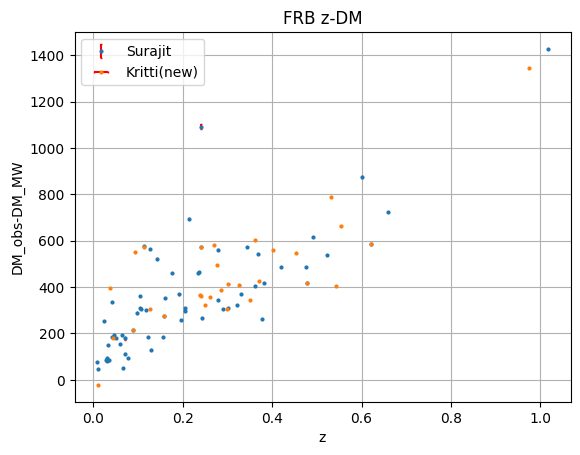

In [6]:
plt.errorbar(df1['z'], df1['DM_ext'], yerr=df1['E_DM_obs'], fmt='o', ecolor='red', capsize=1, label='Surajit',markersize=2)
plt.errorbar(df2['z'], df2['DM_ext'], xerr=df2['E_z'], fmt='o', ecolor='red', capsize=1, label='Kritti(new)',markersize=2)
plt.xlabel('z')
plt.ylabel('DM_obs-DM_MW')
plt.title('FRB z-DM')
plt.legend()
plt.grid(True)
plt.show()

combine data sets

df1 have E_DM, df2 have E_z

In [7]:
data=df1[['FRB','DM_ext','z']]
data=pd.concat([data,df2[['FRB','DM_ext','z']]],ignore_index=True)
data.head()

,FRB,DM_ext,z
0,FRB 20121102A,369.00,0.19273
1,FRB 20171020A,76.10,0.00860
2,FRB 20180301A,370.00,0.33040
3,FRB 20180916B,149.30,0.03370
4,FRB 20180924B,320.92,0.32140


## The simplest case: $\chi^2$ with a single DM parameter

- For the dispersion measure:

We have contributions from the MW ${\rm DM}_{\rm MW}$, the observational limitations ${\rm DM}_{\rm obs}$, the intergalactic medium ${\rm DM}_{\rm IGM}$, the host galaxy ${\rm DM}_{\rm host}$ and potentially the source itself ${\rm DM}_{\rm host}$. Some fiducial values based on [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)] are [in pc/cm$^3$]:

$$
\sigma_{\rm MW} \sim 10, \quad \sigma_{\rm obs} \sim 1.5, \quad \sigma_{\rm IGM} \sim 100, \quad \sigma_{\rm host} \sim 30,
$$

$$
\sigma_{\rm DM_{IGM}} = \sqrt{\sigma_{\rm obs}^2+\sigma_{\rm MW}^2+\sigma_{\rm IGM}^2+\left(\frac{\sigma_{\rm host}}{1+z}\right)^2},
$$

consider uncertainty in Jun-jie Wei's paper first:

In [8]:
def sigma_DM_IGM(z, sigma_obs=1.5, sigma_MW=10, sigma_IGM=100, sigma_host=30):
    a=sigma_obs**2+sigma_MW**2+sigma_IGM**2+(sigma_host/(1+z))**2
    return np.sqrt(a)

F_fid=HUBBLE*OMEGA_BARYONS*f_IGM
print(F_fid)

2.818431


In [9]:
def DM_IGM(z, F, Om=OMEGA_MATTER, w=-1):   

    factor = 3*C_LIGHT*KM_2_MPC*F/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    integral = quad(dDM_integrand_w, 0, z, args=(Om, w))[0]
    
    unit_transform = DM_2_PCCM3
    
    DM = unit_transform*factor*integral + 80
    
    return DM

In [10]:
F_array=np.linspace(0.1,10,1000)
Chi=np.zeros_like(F_array)
sigma_vec=np.vectorize(sigma_DM_IGM)
DM_vec=np.vectorize(DM_IGM)

for idx, F in enumerate(F_array):
    DM_th=DM_vec(data['z'],F)
    sigma=sigma_vec(data['z'])
    Chi[idx]=np.sum((data['DM_ext']-DM_th)**2/sigma**2)

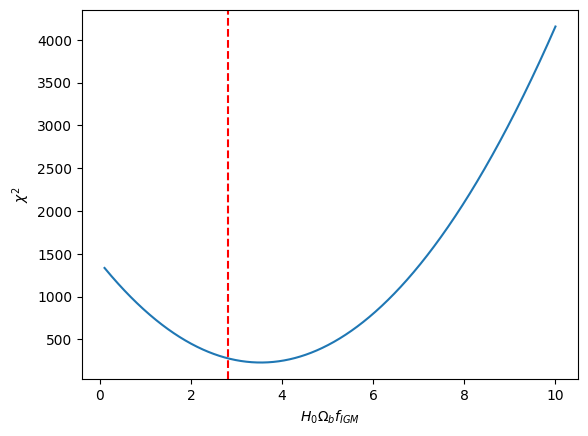

In [11]:
plt.plot(F_array, Chi)
plt.axvline(F_fid, color='r', linestyle='--')
plt.xlabel(r'$H_0 \Omega_b f_{IGM}$')
plt.ylabel(r'$\chi^2$')
plt.show()

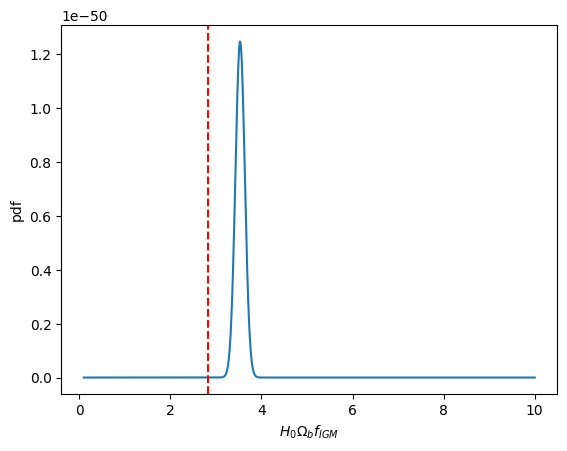

In [12]:
plt.plot(F_array, np.exp(-Chi/2))
plt.axvline(F_fid, color='r', linestyle='--')
plt.xlabel(r'$H_0 \Omega_b f_{IGM}$')
plt.ylabel(r'pdf')
plt.show()

## Macquart. 2020 reproduce

$$ DM=DM_{MW, ISM}+DM_{MW, halo}+DM_{cosmic, IGM}+DM_{host}$$

$ DM_{halo}\approx 50 pc\,cm^{-3} $

$ DM_{MW, ISM}=30 pc\,cm^{-3} $ high Galactic latitudes

$ p_{host}(DM_{host}|\mu,\sigma_{host})=\frac{1}{\sqrt{2\pi}DM \sigma_{host}}\exp\left[-\frac{(\log DM-\mu)^2}{2\sigma_{host}^2}\right] $

median value of $ \exp^\mu$ and variance $ \exp\{(\mu+\sigma_{host}^2)/2\} (\exp\{\sigma_{host}^2\}-1)^{1/2} $

Note $ DM_{host}/(1+z) $

In [13]:
DM_halo=50
DM_ISM=30

def pdf_DM_host(DM, e_mu, sigma_host):
    # e^\mu with 20-200 pc cm^{-3} and \sigma_{host} in 0.2-2.0
    mu=np.log(e_mu)
    pdf=np.exp(-(np.log(DM)-mu)**2/(2*sigma_host**2))/(sigma_host*np.sqrt(2*np.pi)*DM)
    
    return pdf

/var/folders/9w/bbgy16c17_g3tqprqy1t6jcr0000gn/T/ipykernel_24762/2584786251.py:7: RuntimeWarning: divide by zero encountered in log
  pdf=np.exp(-(np.log(DM)-mu)**2/(2*sigma_host**2))/(sigma_host*np.sqrt(2*np.pi)*DM)
/var/folders/9w/bbgy16c17_g3tqprqy1t6jcr0000gn/T/ipykernel_24762/2584786251.py:7: RuntimeWarning: invalid value encountered in divide
  pdf=np.exp(-(np.log(DM)-mu)**2/(2*sigma_host**2))/(sigma_host*np.sqrt(2*np.pi)*DM)


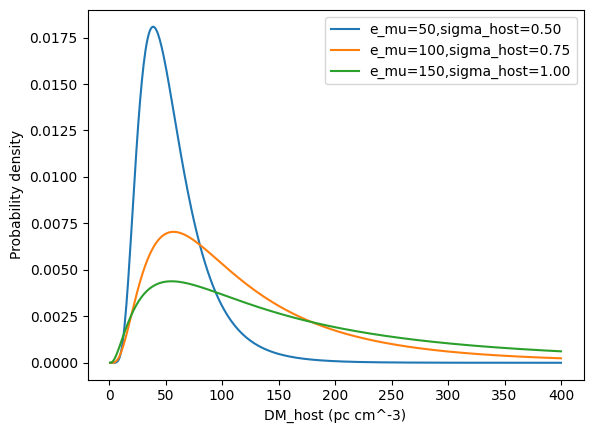

In [14]:
DM_host=np.linspace(0,400,500)
p1=pdf_DM_host(DM_host,e_mu=50,sigma_host=0.50)
p2=pdf_DM_host(DM_host,e_mu=100,sigma_host=0.75)
p3=pdf_DM_host(DM_host,e_mu=150,sigma_host=1.00)

plt.plot(DM_host,p1,label='e_mu=50,sigma_host=0.50')
plt.plot(DM_host,p2,label='e_mu=100,sigma_host=0.75')
plt.plot(DM_host,p3,label='e_mu=150,sigma_host=1.00')
plt.xlabel('DM_host (pc cm^-3)')
plt.ylabel('Probability density')
plt.legend()
plt.show()

$ p_{cosmic, IGM}(\Delta)=A\Delta^{-\beta}\exp\left(-\frac{(\Delta^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right) $

$ \sigma_{DM} $ dominated by physical variance in $DM_{cosmic}$

$\Delta=DM_{cosmic}/<DM_{cosmic}>$

$ \sigma_{DM}=Fz^{-0.5} $

Whith 3D density profile scales as $ \rho \propto r^{-\alpha} $, we have $\beta=(\alpha+1)/(\alpha-1)$

$ \alpha=3$, $\beta=3$

In [28]:
def f_sigma_DM(F, z):
    return F*z**-0.5

def pdf_DM_cosmo(DM, C_0, A, F, z, alpha=3):
    beta=(alpha+1)/(alpha-1)
    sigma_DM=f_sigma_DM(F, z)
    pdf=A*DM**(-beta)*np.exp(-(DM**(-alpha)-C_0)**2/(2*alpha**2*sigma_DM**2))
    return pdf

In [36]:
print(f_sigma_DM(F=1,z=4))

0.5


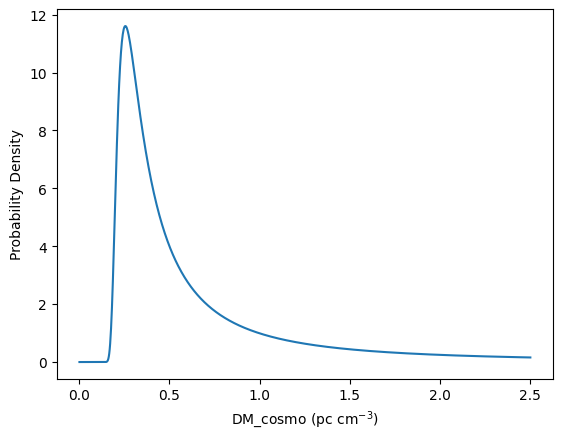

In [42]:
DM_cos=np.linspace(0.001,2.5,1000)
p=pdf_DM_cosmo(DM_cos, C_0=10, A=1, F=10, z=0.2)
plt.plot(DM_cos,p)
plt.xlabel('DM_cosmo (pc cm$^{-3}$)')
plt.ylabel('Probability Density')
plt.show()

In [57]:
from scipy.integrate import quad_vec

def x_pdf_DM_cosmo(DM, C_0, A, F, z, alpha=3):
    beta=(alpha+1)/(alpha-1)
    sigma_DM=f_sigma_DM(F, z)
    pdf=DM*A*DM**(-beta)*np.exp(-(DM**(-alpha)-C_0)**2/(2*alpha**2*sigma_DM**2))
    
    return pdf

def to_C_0(C_0, F, z, alpha=3):
    #result, error = quad(integrand, 0, np.inf, args=(A, beta, alpha, C0, sigma_DM))
    A=1
    x_pdf, error = quad_vec(x_pdf_DM_cosmo, 0, np.inf, args=(C_0, A, F, z, alpha))
    pdf, error = quad_vec(pdf_DM_cosmo, 0, np.inf, args=(C_0, A, F, z, alpha))
    #print(f'x_pdf={x_pdf},pdf={pdf}')
    try:
        ratio=x_pdf/pdf
    except ZeroDivisionError:
        print(f'zero division error for x_pdf={x_pdf},pdf={pdf}')
        ratio=50
    except Exception as e:
        print(f'unknown error for x_pdf={x_pdf},pdf={pdf},error={e}')
    return ratio

vec_C_0=np.vectorize(to_C_0)

In [55]:
print(to_C_0(C_0=45,F=0.5,z=0.9))

x_pdf=0.0,pdf=0.0
nan


/var/folders/9w/bbgy16c17_g3tqprqy1t6jcr0000gn/T/ipykernel_24762/2071203082.py:17: RuntimeWarning: invalid value encountered in scalar divide
  ratio=x_pdf/pdf


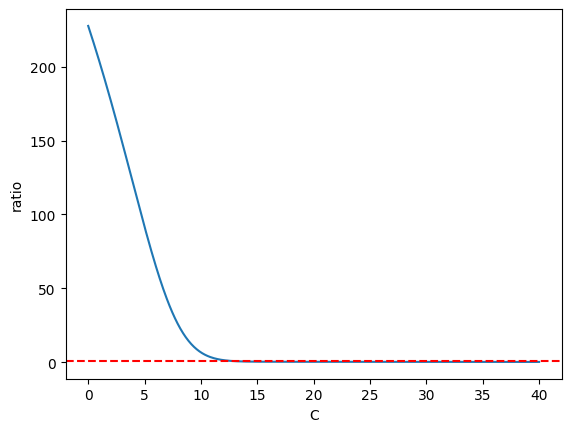

In [60]:
C=np.linspace(0.001,40,500)
ratio=vec_C_0(C,F=0.5, z=0.2)
plt.plot(C,ratio)
plt.axhline(1,color='r',ls='--')
plt.xlabel('C')
plt.ylabel('ratio')
plt.show()

In [63]:
from scipy.optimize import root_scalar

def solve_C0_for_sigma(F, z, alpha=3):
    # only depend on C_0
    def objective(C_0):
        return to_C_0(C_0, F, z, alpha=alpha) - 1
    
    try:
        result = root_scalar(objective,
                           bracket=[1e-10, 40],
                           method='brentq',
                           rtol=1e-6)
        
        if result.converged:
            return result.root
        else:
            print("Failed to converge")
            return None
            
    except ValueError as e:
        print(f"Error: {e}")
        return None

# Example usage
Fs = np.linspace(0.05, 0.5,100)
results = {}

for F in Fs:
    C_0 = solve_C0_for_sigma(F=F, z=0.2)
    results[F] = C_0
    print(f"For F = {F}: C_0 = {C_0}")

/var/folders/9w/bbgy16c17_g3tqprqy1t6jcr0000gn/T/ipykernel_24762/2697667543.py:17: RuntimeWarning: invalid value encountered in scalar divide
  ratio=x_pdf/pdf


Failed to converge
For F = 0.05: C_0 = None
For F = 0.05454545454545455: C_0 = 1.5917678098551664
For F = 0.0590909090909091: C_0 = 1.7071988878430824
For F = 0.06363636363636364: C_0 = 1.823158555332672
For F = 0.06818181818181818: C_0 = 1.9393936640535752
For F = 0.07272727272727272: C_0 = 2.055754309774409
For F = 0.07727272727272727: C_0 = 2.172147801411626
For F = 0.08181818181818182: C_0 = 2.288513803514979
For F = 0.08636363636363636: C_0 = 2.404815440814519
For F = 0.09090909090909091: C_0 = 2.521027125949945
For F = 0.09545454545454546: C_0 = 2.6371323610207655
For F = 0.1: C_0 = 2.753120637254225
For F = 0.10454545454545455: C_0 = 2.868984961502429
For F = 0.1090909090909091: C_0 = 2.9847218123205494
For F = 0.11363636363636363: C_0 = 3.1003286820460074
For F = 0.11818181818181818: C_0 = 3.215806144418023
For F = 0.12272727272727273: C_0 = 3.3311534172024206
For F = 0.12727272727272726: C_0 = 3.4463720220425635
For F = 0.13181818181818183: C_0 = 3.5614631022761665
For F = 0.1